## Mapping Protected Areas in Cabo Verde
This script uses GeoPandas, Cartopy, and Matplotlib to visualize selected protected and conserved areas in Cabo Verde. It highlights both marine and coastal zones with customized styling, labels, and a legend.

## Workflow Overview
### 1. Load and Prepare Data
The dataset is a GeoJSON file containing polygons of protected areas.
The coordinate reference system (CRS) is converted to WGS84 (EPSG:4326).
A subset of areas is selected based on their English names.
A new column type is derived from the realm attribute to classify each area as marine or coastal.

### 2. Map Setup
A Plate Carrée projection is used for simplicity.
The map extent is restricted to the Cabo Verde archipelago ([-26.3, -21., 14.4, 17.5]).
Background styling:
Ocean: light blue (#b8cfe0)
Land: beige (#e8e4dc)
Coastlines: dark gray edges
Gridlines are added with dashed styling and labeled only on the left and bottom.

### 3. Plot Protected Areas
Areas are grouped by type and plotted with distinct colors:
Marine → #2176ae (blue)
Coastal → #3a7d44 (green)
Polygons are semi‑transparent with black edges for clarity.

### 4. Label Placement
Labels are manually positioned using absolute longitude/latitude coordinates to avoid overlap in tight clusters.
Each label is styled with:
White rounded box background
Subtle gray border
Arrow pointing to the polygon centroid

### 5. Legend and Title
A legend explains the color coding of protected area types.
Positioned in the lower left with semi‑transparent background.

Saved to Downloads/cabo_verde_map_final.png


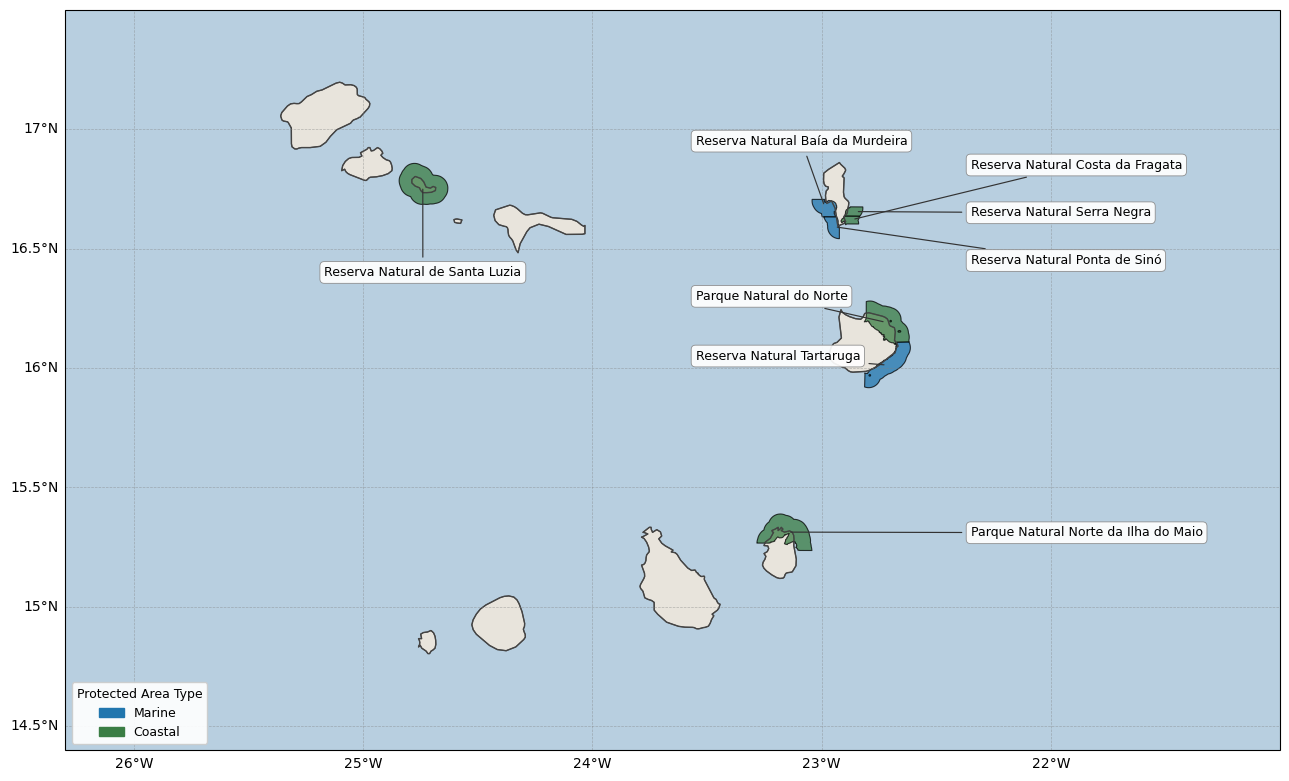

In [11]:
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches

# LOAD DATA 
gdf = gpd.read_file(r"C:\Users\LENOVO\Downloads\protected_conserved_areas_wdpca_polygons.geojson")
gdf = gdf.to_crs(epsg=4326)

names = [
    "Parque Natural Norte da Ilha do Maio",
    "Reserva Natural Casas Velhas",
    "Reserva Natural Tartaruga",
    "Parque Natural do Norte",
    "Reserva Natural Baía da Murdeira",
    "Reserva Natural Ponta de Sinó",
    "Reserva Natural Costa da Fragata",
    "Reserva Natural Serra Negra",
    "Reserva Natural de Santa Luzia"
]
gdf = gdf[gdf["name_eng"].isin(names)].copy()
gdf["type"] = gdf["realm"].str.lower().str.strip()

# MAP SETUP 
fig, ax = plt.subplots(figsize=(13, 10),
                       subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([-26.3, -21., 14.4, 17.5])
ax.set_facecolor("#b8cfe0")
ax.add_feature(cfeature.LAND, facecolor="#e8e4dc", edgecolor="#555", linewidth=0.8)
ax.add_feature(cfeature.COASTLINE, linewidth=1.0, edgecolor="#444")

gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

colors = {"marine": "#2176ae", "coastal": "#3a7d44"}
for t, data in gdf.groupby("type"):
    data.plot(ax=ax, transform=ccrs.PlateCarree(),
              facecolor=colors.get(t, "gray"), edgecolor="black",
              alpha=0.75, linewidth=0.8)

transform = ccrs.PlateCarree()._as_mpl_transform(ax)

# Use absolute text positions (lon, lat) instead of offsets for tight clusters
label_config = {
    # ── Sal cluster 
    # Murdeira N tip:  centroid -22.985, 16.672  → label upper-left
    "Reserva Natural Baía da Murdeira": {
        "text_pos": (-23.55, 16.95), "ha": "left",  "va": "center"},
    # Costa da Fragata: centroid -22.873, 16.620  → label upper-right
    "Reserva Natural Costa da Fragata": {
        "text_pos": (-22.35, 16.85), "ha": "left",  "va": "center"},
    # Serra Negra:      centroid -22.858, 16.655  → label right, mid
    "Reserva Natural Serra Negra": {
        "text_pos": (-22.35, 16.65), "ha": "left",  "va": "center"},
    # Ponta de Sinó:    centroid -22.950, 16.592  → label lower-right
    "Reserva Natural Ponta de Sinó": {
        "text_pos": (-22.35, 16.45), "ha": "left",  "va": "center"},

    # ── Santiago area ─────────────────────────────────────────────────────────
    # Parque Natural do Norte: centroid -22.714, 16.190  → label left
    "Parque Natural do Norte": {
        "text_pos": (-23.55, 16.30), "ha": "left",  "va": "center"},
    # Tartaruga:               centroid -22.710, 16.012  → label left, lower
    "Reserva Natural Tartaruga": {
        "text_pos": (-23.55, 16.05), "ha": "left",  "va": "center"},

    # ── Santa Luzia (isolated) ────────────────────────────────────────────────
    # centroid -24.740, 16.766  → label below into open ocean
    "Reserva Natural de Santa Luzia": {
        "text_pos": (-24.74, 16.40), "ha": "center", "va": "center"},

    # ── Maio ──────────────────────────────────────────────────────────────────
    # centroid -23.153, 15.313  → label right
    "Parque Natural Norte da Ilha do Maio": {
        "text_pos": (-22.35, 15.31), "ha": "left",  "va": "center"},
}

for _, row in gdf.iterrows():
    cx, cy = row.geometry.centroid.coords[0]
    name   = row["name_eng"]
    cfg    = label_config.get(name)
    if cfg is None:
        continue
    tx, ty = cfg["text_pos"]

    ax.annotate(
        name,
        xy=(cx, cy),
        xycoords=transform,
        xytext=(tx, ty),
        textcoords=transform,
        fontsize=9,
        ha=cfg["ha"],
        va=cfg["va"],
        bbox=dict(facecolor="white", alpha=0.92, edgecolor="#888",
                  boxstyle="round,pad=0.35", linewidth=0.6),
        arrowprops=dict(arrowstyle="-", color="#333", lw=0.85,
                        shrinkA=3, shrinkB=3),
        zorder=12,
    )

# ── LEGEND & TITLE ───────────────────────────────────────────────────────────
ax.legend(
    handles=[mpatches.Patch(color="#2176ae", label="Marine"),
             mpatches.Patch(color="#3a7d44", label="Coastal")],
    title="Protected Area Type", loc="lower left",
    fontsize=9, title_fontsize=9, framealpha=0.92)


plt.tight_layout()
plt.savefig(r"C:\Users\LENOVO\Downloads\cabo_verde_map_final.png", dpi=200, bbox_inches="tight")
print("Saved to Downloads/cabo_verde_map_final.png")
plt.show()